# Confidence Intervals in Data Analytics


Implement the 4 steps that we learnt regarding distributions namely:

1. Understand the Data Type: Continuous or discrete.
2. Identify the Analytical Question: Determine which distribution fits your question.
3. Calculate Descriptive Statistics: Compute and visualize summary statistics.
4. Interpret the Graph and Descriptive Statistics: Analyze the data’s distribution and patterns.

To ultimately calculate the CI.

Keep in mind to check the following when selecting the method to calculate CI:

- Sample Size
- Population Parameters are known or unknown

---

# Case Study 1:

Scenario:
A tech company has introduced a new smartphone model. The battery life (in hours) of the smartphone is a key feature, and the company conducted a test on a sample of 50 units. The battery life data from this test is normally distributed. However, since this is a new product, the population mean and standard deviation of battery life are unknown.

Your task is to calculate the 95% confidence interval for the mean battery life of the smartphone.

Dataset: battery_life

In [17]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [18]:
df = pd.read_csv("data/battery_life.csv")

In [19]:
df

,BatteryLife
0,10.993428
1,9.723471
2,11.295377
3,13.046060
4,9.531693
5,9.531726
6,13.158426
7,11.534869
8,9.061051
9,11.085120


In [20]:
sample_mean = df['BatteryLife'].mean()
sample_std = df['BatteryLife'].std()
sample_median = df['BatteryLife'].median()
n = len(df)

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Sample Median: {sample_median:.2f}")

Sample Mean: 9.55
Sample Standard Deviation: 1.87
Sample Median: 9.53


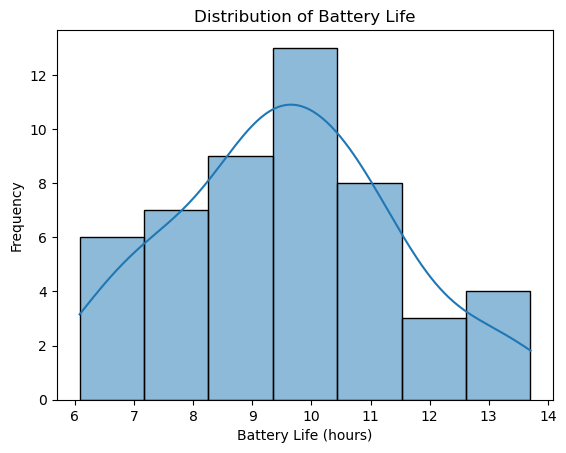

In [21]:
# Visualize the distribution
sns.histplot(df['BatteryLife'], kde=True)
plt.title("Distribution of Battery Life")
plt.xlabel("Battery Life (hours)")
plt.ylabel("Frequency")
plt.show()

In [22]:
df['BatteryLife'].skew() # Checking skewness value  well within the expected bounds of  -0.5 and +0.5

np.float64(0.14017158076560743)

When the population standard deviation (σ) is known, we use the z-distribution to calculate confidence intervals.
When the population standard deviation is unknown (like in your case) and the sample size is relatively small (n < 30–50), we use the t-distribution with n−1 degrees of freedom.

In [23]:
# CI=xˉ±t**⋅​s​/sqrt(n)
# For your dataset,n=50, so df=50−1=49, use a t-distribution table, look under df = 49 and two-tailed 95% confidence.

In [24]:
#how to calculate t_critical value?
# from scipy import stats
# df = 49
# t_crit = stats.t.ppf(0.975, df)
# print(t_crit)  # ≈ 2.009


In [25]:
# t-critical value for 95% confidence
# t_crit = stats.t.ppf(0.975, df=n-1)

# # Margin of error
# margin_error = t_crit * (sample_std / np.sqrt(n))

# # Confidence interval
# ci_lower = sample_mean - margin_error
# ci_upper = sample_mean + margin_error

# print(f"Sample mean: {sample_mean:.2f}")
# print(f"Sample std: {sample_std:.2f}")
# print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

In [ ]:
# 95% CI meaning we want to capture the middle 95% of the data. This leaves 5% of the data i.e. 2.5% on either tail
# Hence why we use .975 to establish upper bound of the CI and lower bound
from scipy.stats import norm
z_score = norm.ppf(0.975) # Z-score since the data is normal and population params are known
margin_of_error = z_score * (1.87/ np.sqrt(n))  # 1.87 is the standard error 
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error
print(f"95% Confidence Interval for the Mean Dosage Strength: ({ci_lower:.2f}, {ci_upper:.2f}) mg")

95% Confidence Interval for the Mean Dosage Strength: (9.03, 10.07) mg


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Population: all student heights
np.random.seed(0) # this ensures we can always re-run this block of code and have the same results otherwise it would generate a different sample on each run
population = np.random.normal(9.55,1.87 , 5000)

# Sample of 30 students
# sample = np.random.choice(population, 30, replace=False)
# sample_mean = np.mean(sample)
# sample_std = np.std(sample, ddof=1) # investigate what the ddof parameter does...

In [28]:
# # SciPy one-liner (assuming population std is known)
# ci = norm.interval(0.95, loc=sample_mean, scale=5/np.sqrt(n))
# print(f"SciPy norm.interval CI: {ci}")

In [37]:
import pandas as pd
import numpy as np
from scipy import stats

# Load dataset
df = pd.read_csv("data/battery_life.csv")

# Select the column (assuming it's named 'battery_life')
data = df["BatteryLife"].dropna()  # drop missing values if any

# Sample statistics
mean = np.mean(data)
sem = stats.sem(data)   # Standard error of the mean

# 95% confidence interval
ci = stats.norm.interval(confidence=0.95, loc=mean, scale=sem)
print("Mean:", mean)
print("95% CI:", ci)
print("Sem", sem)



Mean: 9.54905218948772
95% CI: (np.float64(9.031462135292635), np.float64(10.066642243682804))
Sem 0.2640814108206927


In [43]:
np.random.seed(0) # this ensures we can always re-run this block of code and have the same results otherwise it would generate a differnt sample on each run
population = np.random.normal(9.55, 1.87, 1500)

# Sample of 30 students
sample = np.random.choice(population, 50, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1) # investigate what the ddof parameter does...

z = norm.ppf(0.975)  # percent point function, which is the inverse of the CDF (cumulative distribution function).
margin_error = z * (sample_std / np.sqrt(len(sample))) # how far above or below the sample mean we go to capture the true mean with 95% confidence.
ci_lower = sample_mean - margin_error # Lower bound of the confidence interval.
ci_upper = sample_mean + margin_error # Upper bound of the confidence interval.

print(f"Sample Mean: {sample_mean:.2f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

Sample Mean: 9.72
95% CI: (9.23, 10.21)


---

# Case Study 2: Interpreting Confidence Interval for Product Defect Rate
Scenario:
You work as a quality control analyst at a manufacturing company. 

Your team has been monitoring the defect rate of a specific product. 

Over the past month, you randomly inspected 500 units and found that the defect rate was calculated along with a 95% confidence interval for the true defect rate, which is (3.5%, 6.5%).

```Task:
Interpret this confidence interval within the context of quality control. Address the following questions:

What does the confidence interval tell you about the true defect rate of the product?

Can you confidently say that the defect rate is below the company's acceptable threshold of 5%? Why or why not?

How would you explain these results to the production team? 
```

In [30]:
#The confidence interval (3.5%, 6.5%) provides a range in which we are 95% confident that the true average defect rate of all the specific products lies

#This means that, based on the sample data, the actual average defect rate could be as low as 3.5% or as high as 6.5%

In [31]:
#  No, you cannot confidently say that the average defect rate is within acceptable threshold. 
# While the lower bound of the confidence interval (3.5%) is below the limit, 
# the upper bound (6.5%) exceeds the threshold. 
# This suggests that it is possible, based on your data, 
# that the average defect rate in the production could be above the acceptable threshold of 5%.

In [32]:
#  "Our study shows that the average defect rate of all the specific products likely falls between 3.5% and 6.5%. 
# While the defect rates in some months lower than the acceptable threshold of 5%, 
# it is also possible that the defect rate is exceeding this threshold. 
# Therefore, it is important to consider strategies to improve the quality and reduce the defect rate.
